# Analyze results from $k$ and $m$ grid search

Produces Figures 3c and 3d.

It requires that the parameter estimation has been completed and there exists a file with those results. Edit the location of those files below.

## Load required packages

In [1]:
%matplotlib widget
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import numpy as np
from statsmodels.formula import api as smf
import os
import seaborn as sns
from scipy.stats import ttest_ind
from sklearn.metrics import mean_squared_error
from estimator import Estimator
from src import pyxfunc
import time

## User-defined parameters

In [2]:
growth_data_file = "data/growth_data_df.csv"
config_file = "config_files/config_km.json"

result_path = "/data/hirschmg/tumor_dynamics/2026/final_results/k_m/"

figure_save_path = "figures/" # Set to None to not save figures

best_value_save_path = "bests/" # Set to None to not save

## Setup

In [3]:
groups = ["Grp. B1 nude (100% C1)", "Grp. B2 nude (80% C1; 20% C11)", "Grp. B3 nude (50% C1; 50% C11)", "Grp. B4 nude (20% C1; 80% C11)", "Grp. B5 nude (100% C11)"]
growth_df = pd.read_csv(growth_data_file)
exclude = [456, 458, 461, 464, 471, 474, 478, 482, 483, 426, 428, 429, 430, 434, 437, 438, 442, 443, 451, 642, 662]
growth_df = growth_df[~(growth_df["id"].isin(exclude))]
es = Estimator(config_file)

## Read in and prep data

In [4]:
df = []
for fname in [f for f in os.listdir(result_path)]:
    temp = pd.read_csv(result_path+fname)
    temp = temp[~(temp["id"].isin(exclude))]
    df += [temp]
df = pd.concat(df)
df = df.drop_duplicates()
df["error"] = df["error"].astype(float)
df["log_error"] = np.log(df["error"])
df

,group,id,g1,g11,m,k,error,winner,log_error
0,Grp. B2 nude (80% C1; 20% C11),460,0.166,0.127,-0.005,0.165,8.112252e+05,0.0,13.606301
1,Grp. B2 nude (80% C1; 20% C11),462,0.166,0.127,-0.005,0.165,4.894221e+03,0.0,8.495810
2,Grp. B2 nude (80% C1; 20% C11),463,0.166,0.127,-0.005,0.165,3.904548e+05,0.0,12.875067
3,Grp. B2 nude (80% C1; 20% C11),465,0.166,0.127,-0.005,0.165,2.872781e+03,0.0,7.963036
4,Grp. B2 nude (80% C1; 20% C11),460,0.166,0.127,-0.005,0.170,8.685732e+05,0.0,13.674607
...,...,...,...,...,...,...,...,...,...
23192,Grp. B4 nude (20% C1; 80% C11),472,0.171,0.142,0.000,1.000,6.337426e+08,0.0,20.267153
23193,Grp. B4 nude (20% C1; 80% C11),473,0.171,0.142,0.000,1.000,9.518712e+08,0.0,20.673940
23194,Grp. B4 nude (20% C1; 80% C11),475,0.171,0.142,0.000,1.000,1.100495e+09,0.0,20.819026
23195,Grp. B4 nude (20% C1; 80% C11),476,0.171,0.142,0.000,1.000,4.574806e+08,0.0,19.941245


## Find the top $n$ tuples with lowest error

In [9]:
n = 100
bests = []
for mid in df["id"].unique():
    m_df = df[df["id"] == mid]
    m_df = m_df.sort_values("error").reset_index()
    cutoff = m_df.loc[(n-1),"error"]
    m_df = m_df[m_df["error"] <= cutoff]
    bests += [m_df]
bests = pd.concat(bests)
bests = bests.sort_values(["group", "id"])
bests

,index,group,id,g1,g11,m,k,error,winner,log_error
0,1692,Grp. B2 nude (80% C1; 20% C11),460,0.166,0.142,-0.025,-0.010,8686.370697,0.0,9.069510
1,868,Grp. B2 nude (80% C1; 20% C11),460,0.166,0.141,-0.025,-0.010,8704.985181,0.0,9.071651
2,8,Grp. B2 nude (80% C1; 20% C11),460,0.166,0.127,-0.020,-0.010,8749.460075,0.0,9.076747
3,1688,Grp. B2 nude (80% C1; 20% C11),460,0.166,0.142,-0.025,-0.015,8805.163177,0.0,9.083094
4,864,Grp. B2 nude (80% C1; 20% C11),460,0.166,0.141,-0.025,-0.015,8828.586690,0.0,9.085750
...,...,...,...,...,...,...,...,...,...,...
95,33036,Grp. B4 nude (20% C1; 80% C11),477,0.166,0.142,-0.155,0.120,5744.162532,0.0,8.655939
96,32492,Grp. B4 nude (20% C1; 80% C11),477,0.166,0.142,-0.145,0.115,5746.957048,0.0,8.656426
97,29361,Grp. B4 nude (20% C1; 80% C11),477,0.166,0.127,-0.125,0.105,5747.386683,0.0,8.656501
98,33590,Grp. B4 nude (20% C1; 80% C11),477,0.166,0.142,-0.165,0.125,5751.585504,0.0,8.657231


In [6]:
if best_value_save_path:
    bests.to_csv(best_value_save_path+"km_{}.csv".format(n))

In [11]:
def plot_scatterplots():
    for i in [1, 2, 3]:
        fig = plt.figure(figsize=(2,2))
        sns.scatterplot(bests[bests["group"]==groups[i]], x="m", y="k", hue="id", palette="bright", marker="o", edgecolors="white", s=5, alpha=.7)
        plt.xlim([-1.1, .1])
        plt.ylim([-.1, 1.1])
        plt.tight_layout()
        plt.legend(prop={"size":5})
        if figure_save_path:
            plt.savefig(figure_save_path+"m_vs_k_{}.svg".format(i))
        plt.show()

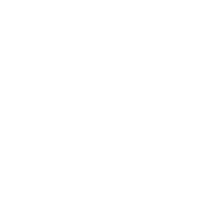

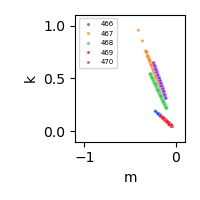

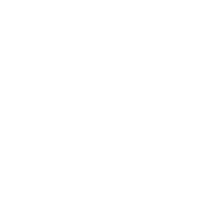

In [12]:
plot_scatterplots()

## Plot optimal values

In [41]:
def plot_results_best(bests, n):
    ylim = (growth_df[growth_df["group"].isin(groups)]["size"].max())+10
    xlim = growth_df[growth_df["group"].isin(groups)]["day"].max()+2

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10,5))
    for i in range(1,4):
        axes[0][i-1].set_ylim([-1, np.abs(ylim)])
        axes[0][i-1].set_xlim([6, np.abs(xlim)])
        # Plot true data
        group_df = growth_df[growth_df["group"] == groups[i]]
        for mid in group_df["id"].unique():
            axes[0][i-1].plot(group_df[group_df["id"]==mid]["day"], group_df[group_df["id"]==mid]["size"], color="black", linewidth=1)
            
            # Plot estimated data
            init = es.get_init(groups[i], mid)
            end_time = group_df[group_df["id"]==mid]["day"].max()
            
            for j in range(n):
                g1 = bests[bests["id"]==mid]["g1"].tolist()[j]
                g11 = bests[bests["id"]==mid]["g11"].tolist()[j]
                k = bests[bests["id"]==mid]["k"].tolist()[j]
                m = bests[bests["id"]==mid]["m"].tolist()[j]
                sol = pyxfunc.run(init[0], init[1], init[2], 7.0, end_time, np.inf, es.cutoff_0_raw, es.cutoff_0_percent, init[2], 
                                    g1, g11, m, k, 0, 0, 0, 0, 0.01)
                
                sol[0] = np.asarray(sol[0])
                sol[1] = np.asarray(sol[1])
                sol[2] = np.asarray(sol[2])
                sol[3] = np.asarray(sol[3])
                
                # plot the winning subline second so it shows up
                if sol[0][-1] > sol[1][-1]: 
                    axes[0][i-1].plot(sol[3], ((sol[1])), color="blue", label="Invasive", alpha=0.6)
                    axes[0][i-1].plot(sol[3], ((sol[0])), color="orange", label="Proliferative", alpha=0.8)
                    color = "orange"
                else:
                    axes[0][i-1].plot(sol[3], ((sol[0])), color="orange", label="Invasive", alpha=0.8)
                    axes[0][i-1].plot(sol[3], ((sol[1])), color="blue", label="Proliferative", alpha=0.6)
                    color = "blue"
        
                # plot the ratios
                axes[1][i-1].plot(sol[0]+sol[1], sol[0]/(sol[0]+sol[1]), color="orange", label="Invasive")
                axes[1][i-1].plot(sol[0]+sol[1], sol[1]/(sol[0]+sol[1]), color="blue", label="Proliferative")

            axes[0][i-1].set_title(groups[i][5:7])
            
    axes[1][0].set_ylabel("Percentage of subclone")
    plt.tight_layout()
    if figure_save_path:
        plt.savefig(figure_save_path+"nude_admix_predictions.svg")
    plt.show()

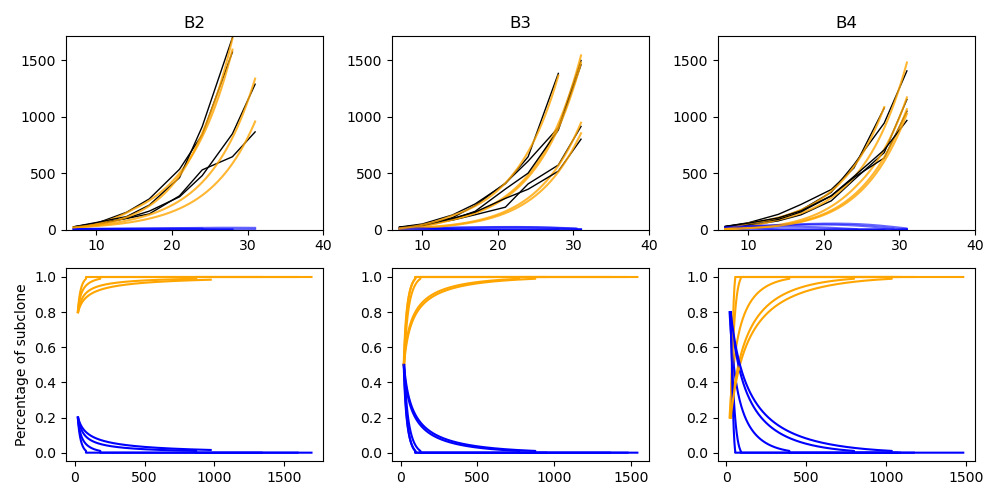

In [42]:
plot_results_best(bests, 1)

In [13]:
plt.close("all")

## Plot $k$ and $m$ distributions per group

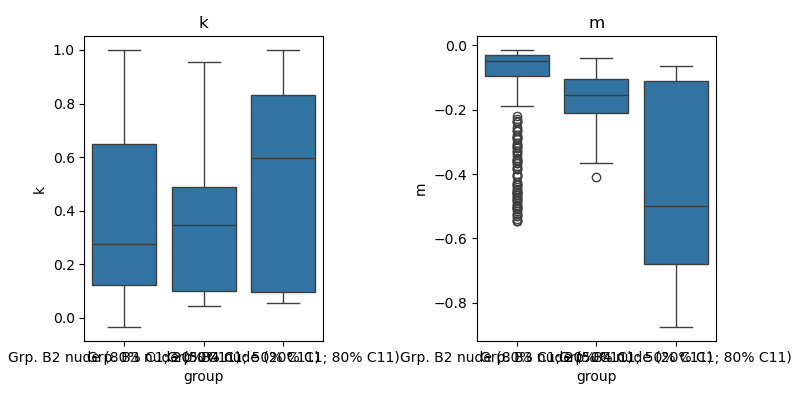

In [13]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
sns.boxplot(bests, x="group", y="k", ax=axes[0])
axes[0].set_title("k")
sns.boxplot(bests, x="group", y="m", ax=axes[1])
axes[1].set_title("m")
plt.tight_layout()
plt.show()

## Calculate significant differences between $k$ and $m$ per group

In [44]:
print("k B2 vs B3:", ttest_ind(bests[bests["group"]==groups[1]]["k"], bests[bests["group"]==groups[2]]["k"]).pvalue)
print("k B2 vs B4:", ttest_ind(bests[bests["group"]==groups[1]]["k"], bests[bests["group"]==groups[3]]["k"]).pvalue)
print("k B3 vs B4:", ttest_ind(bests[bests["group"]==groups[2]]["k"], bests[bests["group"]==groups[3]]["k"]).pvalue)

print("m B2 vs B3:", ttest_ind(bests[bests["group"]==groups[1]]["m"], bests[bests["group"]==groups[2]]["m"]).pvalue)
print("m B2 vs B4:", ttest_ind(bests[bests["group"]==groups[1]]["m"], bests[bests["group"]==groups[3]]["m"]).pvalue)
print("m B3 vs B4:", ttest_ind(bests[bests["group"]==groups[2]]["m"], bests[bests["group"]==groups[3]]["m"]).pvalue)

k B2 vs B3: 0.0023705131082486335
k B2 vs B4: 1.1558738953481187e-07
k B3 vs B4: 3.6950407108144025e-20
m B2 vs B3: 1.9407688148226548e-08
m B2 vs B4: 4.150752541527255e-70
m B3 vs B4: 7.761746160100144e-75
